# Question 1 (10 marks)

You are provided with a dataset of shape (1000, 10), where each row represents a pair of an end-effector position and its corresponding joint angles. Each row consists of:

(1) The first 3 dimensions: robot end-effector position (x, y, z)
(2) The last 7 dimensions: corresponding robot joint angles (7-DOF robot arm)

Answer the question below:

Given a new end-effector position (-0.18067622, -0.18449534, 1.61964518), use KNN to predict its corresponding joint angles (i.e., solving the inverse kinematics problem)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

The dataset include 1000 samples/trajectories


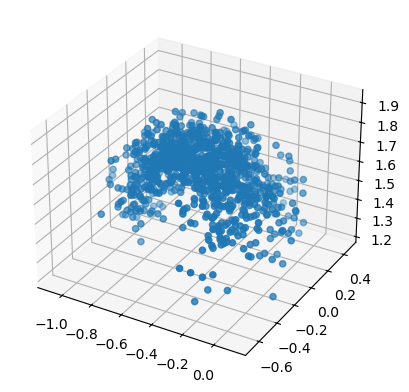

In [3]:
data = np.load("data.npy")
eef_position = data[..., 0:3]   # x, y, z coordinates
joint_angles = data[..., 3:]    # joint angles for a seven degree of freedom robot
print("The dataset include {} samples/trajectories".format(len(data)))

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(eef_position[:, 0], eef_position[:, 1], eef_position[:, 2])
plt.show()

Predicted joint angles: [-0.2269943   0.63793802  0.16552673 -0.08955702 -0.17323659 -0.19209674
  0.28553552]
Average distance to 20 nearest neighbors: 0.057804


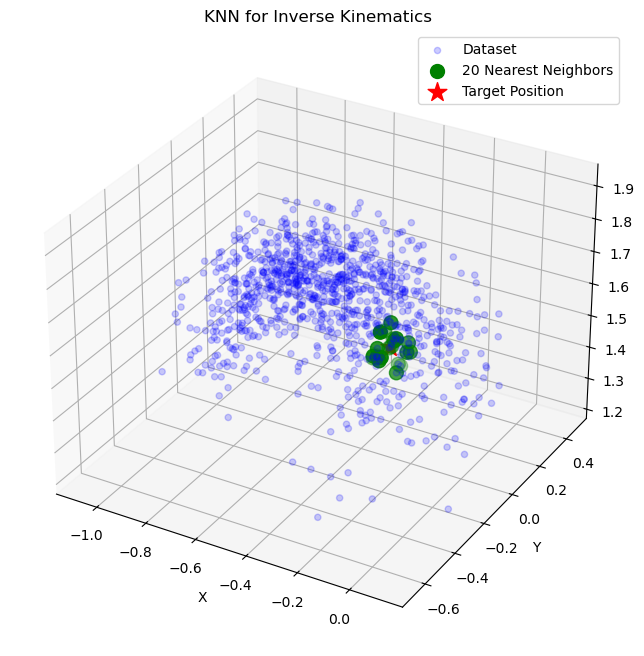

In [4]:
new_eef_pos = np.array([-0.18067622, -0.18449534, 1.61964518]) # desired end-effector position

# TODO: write your code here, implement KNN to solve the inverse kinematics problem.

def euclidean_distance(point1, point2):
    """
    Calculate the Euclidean distance between two points in 3D space.
    
    Parameters:
    -----------
    point1 : numpy.ndarray
        First 3D point (x, y, z)
    point2 : numpy.ndarray
        Second 3D point (x, y, z)
    
    Returns:
    --------
    float
        Euclidean distance between the two points
    """
    return np.sqrt(np.sum((point1 - point2)**2))



def find_k_nearest_neighbors(eef_positions, desired_position, k=5):
    """
    Find the k-nearest neighbors to the desired position.
    
    Parameters:
    -----------
    eef_positions : numpy.ndarray
        Array of end effector positions, shape (n_samples, 3)
    desired_position : numpy.ndarray
        Target position to find neighbors for, shape (3,)
    k : int, default=5
        Number of nearest neighbors to find
    
    Returns:
    --------
    numpy.ndarray
        Indices of the k-nearest neighbors
    numpy.ndarray
        Distances to the k-nearest neighbors
    """
    distances = np.array([euclidean_distance(desired_position, pos) for pos in eef_positions])
    nearest_indices = np.argsort(distances)[:k]
    return nearest_indices, distances[nearest_indices]


def knn_regression(eef_positions, joint_angles, desired_position, k=5):
    """
    Predict joint angles for a desired end effector position using KNN regression.
    
    Parameters:
    -----------
    eef_positions : numpy.ndarray
        Array of end effector positions, shape (n_samples, 3)
    joint_angles : numpy.ndarray
        Array of joint angles corresponding to eef_positions, shape (n_samples, 7)
    desired_position : numpy.ndarray
        Target position to predict joint angles for, shape (3,)
    k : int, default=5
        Number of nearest neighbors to use
    
    Returns:
    --------
    numpy.ndarray
        Predicted joint angles for the desired position
    float
        Average distance to the k nearest neighbors
    """
    # Get indices and distances of k nearest neighbors
    indices, distances = find_k_nearest_neighbors(eef_positions, desired_position, k)
    
    # Compute weights based on inverse distance
    weights = 1.0 / (distances + 1e-10)  # Add small epsilon to avoid division by zero
    weights = weights / np.sum(weights)
    
    # Predict joint angles as weighted average
    predicted_angles = np.sum(joint_angles[indices] * weights[:, np.newaxis], axis=0)
    
    return predicted_angles, np.mean(distances)

# Set the number of neighbors to use
k = 20

# Apply KNN regression to predict joint angles for the new position
predicted_joint_angles, avg_distance = knn_regression(eef_position, joint_angles, new_eef_pos, k=k)

# Print results
print(f"Predicted joint angles: {predicted_joint_angles}")
print(f"Average distance to {k} nearest neighbors: {avg_distance:.6f}")

# Visualize the target position and its k nearest neighbors
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

# Plot all data points (semi-transparent)
ax.scatter(eef_position[:, 0], eef_position[:, 1], eef_position[:, 2], color='blue', alpha=0.2, label='Dataset')

# Get the k nearest neighbors
nn_indices, _ = find_k_nearest_neighbors(eef_position, new_eef_pos, k)
nn_positions = eef_position[nn_indices]

# Plot the nearest neighbors
ax.scatter(nn_positions[:, 0], nn_positions[:, 1], nn_positions[:, 2], color='green', s=100, label=f'{k} Nearest Neighbors')

# Plot the target position
ax.scatter(new_eef_pos[0], new_eef_pos[1], new_eef_pos[2], color='red', s=200, marker='*', label='Target Position')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.title('KNN for Inverse Kinematics')
plt.show()


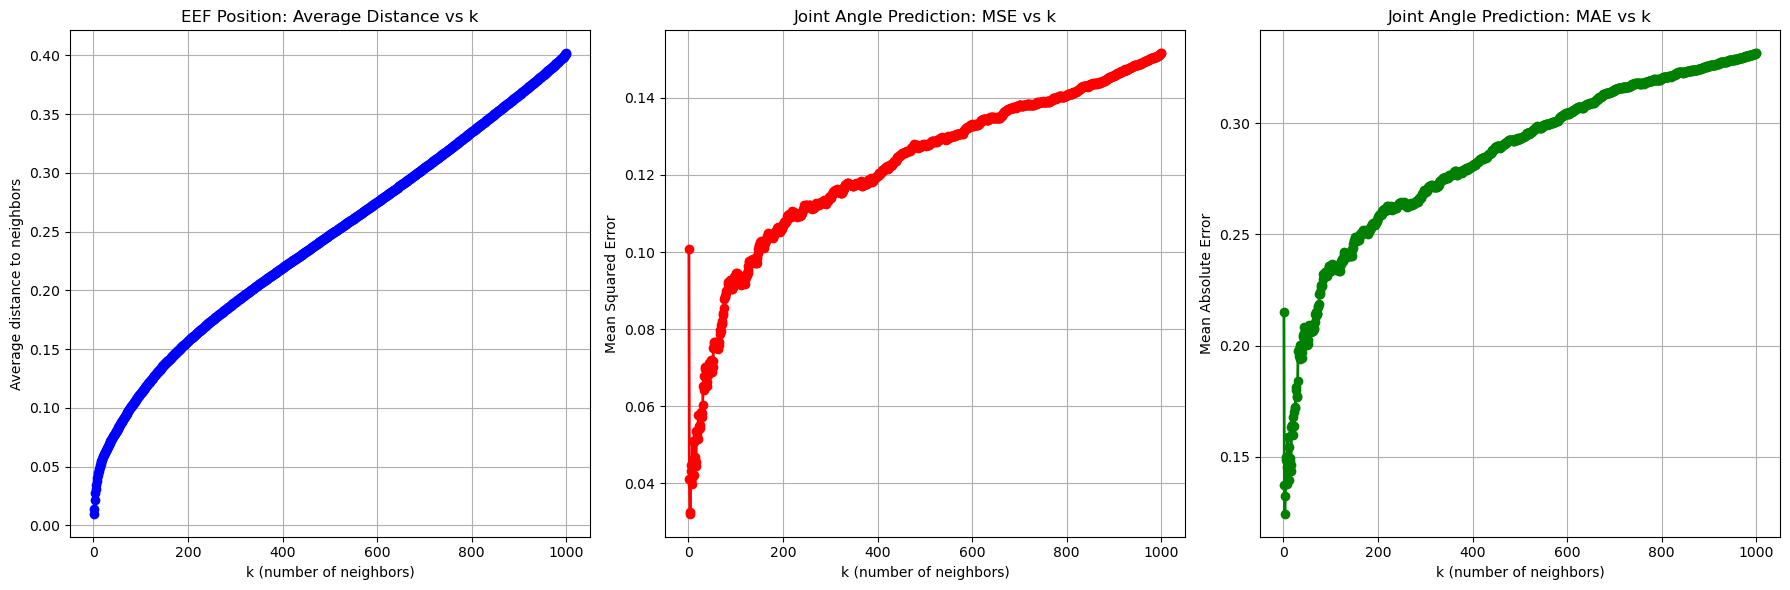

Best k value based on minimum joint angle MSE: 3
Predicted joint angles with k=3: [-0.23903152  0.63516577  0.22546125 -0.18156984 -0.14511491 -0.35870896
  0.58434243]
Actual joint angles: [-0.28158251  0.64710445  0.64139232 -0.0452992  -0.29836178 -0.27488041
  0.61142905]
Joint angle MSE with k=3: 0.032110
Joint angle MAE with k=3: 0.124408

Per-joint absolute errors:
Joint 1: 0.042551
Joint 2: 0.011939
Joint 3: 0.415931
Joint 4: 0.136271
Joint 5: 0.153247
Joint 6: 0.083829
Joint 7: 0.027087


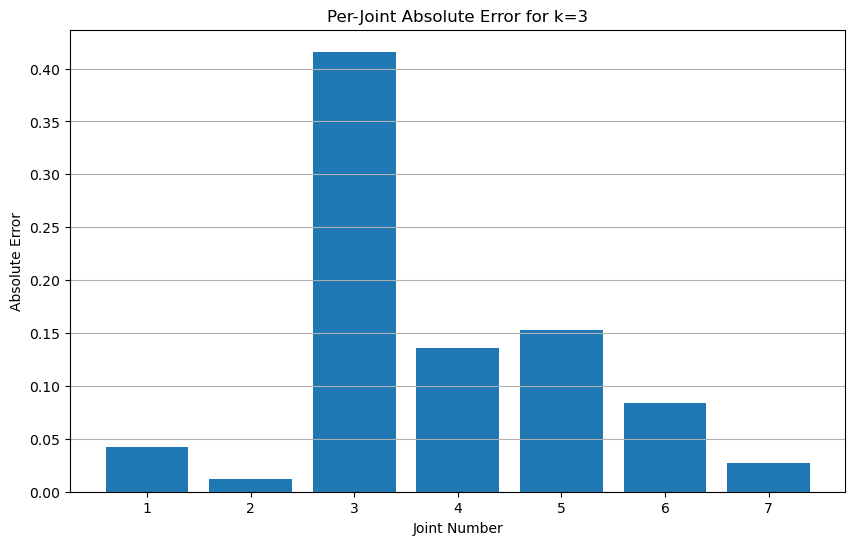

In [ ]:
# Define the desired end-effector position and its ground truth joint angles
new_eef_pos = np.array([-0.18067622, -0.18449534, 1.61964518])
actual_joint_angles = np.array([-0.28158251, 0.64710445, 0.64139232, -0.0452992, -0.29836178, -0.27488041, 0.61142905])

# Define a range of k values to test
k_values = range(1, 1001)  # Test k from 1 to 1000

# Lists to store metrics for each k
avg_distances = []  # Average distance to neighbors
joint_angle_mse = []  # Mean Squared Error for joint angles
joint_angle_mae = []  # Mean Absolute Error for joint angles

# For each k value
for k in k_values:
    # Get predicted joint angles
    predicted_angles, avg_dist = knn_regression(eef_position, joint_angles, new_eef_pos, k=k)
    avg_distances.append(avg_dist)
    
    # Calculate error metrics between predicted and actual joint angles
    mse = np.mean((predicted_angles - actual_joint_angles) ** 2)
    mae = np.mean(np.abs(predicted_angles - actual_joint_angles))
    
    joint_angle_mse.append(mse)
    joint_angle_mae.append(mae)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot average distance to neighbors in EEF space
axes[0].plot(k_values, avg_distances, 'o-', color='blue', linewidth=2)
axes[0].set_xlabel('k (number of neighbors)')
axes[0].set_ylabel('Average distance to neighbors')
axes[0].set_title('EEF Position: Average Distance vs k')
axes[0].grid(True)

# Plot Mean Squared Error for joint angles
axes[1].plot(k_values, joint_angle_mse, 'o-', color='red', linewidth=2)
axes[1].set_xlabel('k (number of neighbors)')
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('Joint Angle Prediction: MSE vs k')
axes[1].grid(True)

# Plot Mean Absolute Error for joint angles
axes[2].plot(k_values, joint_angle_mae, 'o-', color='green', linewidth=2)
axes[2].set_xlabel('k (number of neighbors)')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].set_title('Joint Angle Prediction: MAE vs k')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Find the best k value based on minimum MSE for joint angles
best_k_mse = k_values[np.argmin(joint_angle_mse)]
print(f"Best k value based on minimum joint angle MSE: {best_k_mse}")

# Predict joint angles using the best k
best_predicted_angles, _ = knn_regression(eef_position, joint_angles, new_eef_pos, k=best_k_mse)
print(f"Predicted joint angles with k={best_k_mse}: {best_predicted_angles}")
print(f"Actual joint angles: {actual_joint_angles}")
print(f"Joint angle MSE with k={best_k_mse}: {np.min(joint_angle_mse):.6f}")
print(f"Joint angle MAE with k={best_k_mse}: {joint_angle_mae[np.argmin(joint_angle_mse)]:.6f}")

# Calculate per-joint errors for the best k
joint_errors = np.abs(best_predicted_angles - actual_joint_angles)
print("\nPer-joint absolute errors:")
for i, error in enumerate(joint_errors):
    print(f"Joint {i+1}: {error:.6f}")

# Plot per-joint errors
plt.figure(figsize=(10, 6))
plt.bar(range(1, 8), joint_errors)
plt.xlabel('Joint Number')
plt.ylabel('Absolute Error')
plt.title(f'Per-Joint Absolute Error for k={best_k_mse}')
plt.xticks(range(1, 8))
plt.grid(axis='y')
plt.show()

# Discuss the results in your report

For the given end-effector position (-0.18067622, -0.18449534, 1.61964518), the actual joint angles are (-0.28158251, 0.64710445, 0.64139232, -0.0452992, -0.29836178, -0.27488041, 0.61142905).

Experiment with different values of K and evaluate their performance. Then, analyze and discuss your findings in the report. You do not need to write code for this section—focus on interpreting and explaining the results in your discussion.

K value: 300
Predicted joint angles: [-0.17693769  0.513533   -0.00846332 -0.11946382 -0.07184043 -0.08354912
  0.10464884]
Average distance to 300 nearest neighbors: 0.190085
Mean Squared Error: 0.114479
Mean Absolute Error: 0.269553


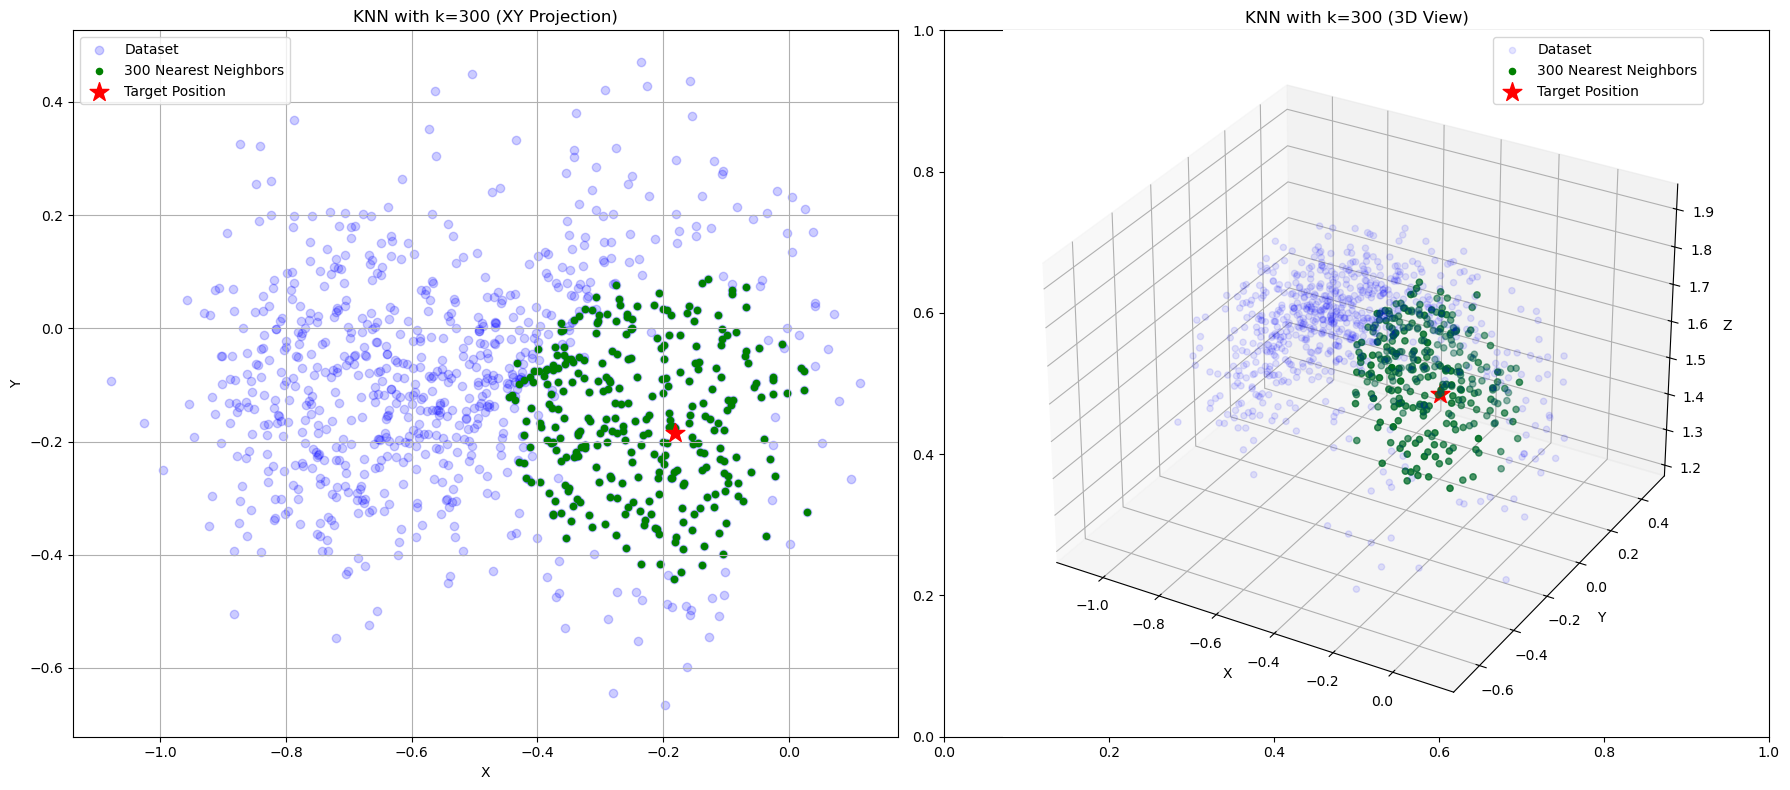

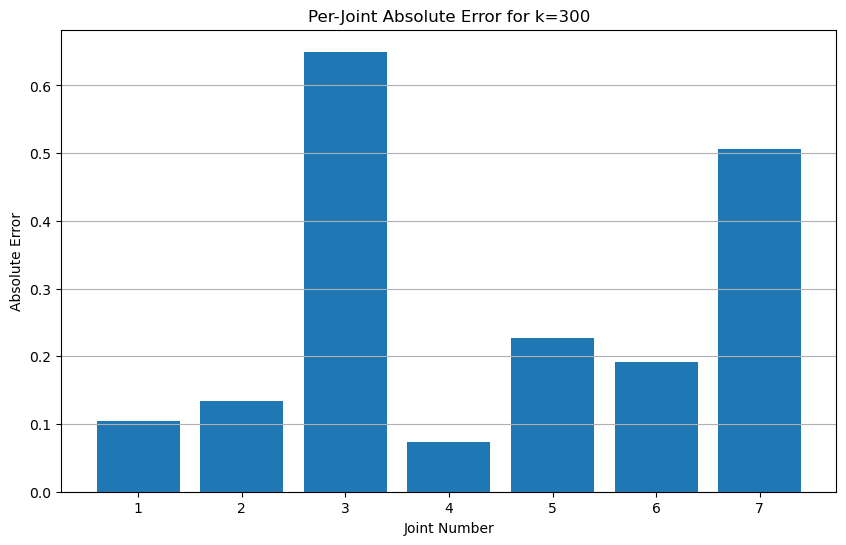

In [9]:
# TODO: discuss your results in your report (5 marks), no code required here, no code required for the report.


# Set specific k value
k = 300

# Apply KNN regression to predict joint angles for the new position
predicted_joint_angles, avg_distance = knn_regression(eef_position, joint_angles, new_eef_pos, k=k)

# Print results
print(f"K value: {k}")
print(f"Predicted joint angles: {predicted_joint_angles}")
print(f"Average distance to {k} nearest neighbors: {avg_distance:.6f}")

# Calculate error metrics between predicted and actual joint angles
mse = np.mean((predicted_joint_angles - actual_joint_angles) ** 2)
mae = np.mean(np.abs(predicted_joint_angles - actual_joint_angles))
print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")

# Create visualization with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Visualization of k-nearest neighbors
ax1.scatter(eef_position[:, 0], eef_position[:, 1], color='blue', alpha=0.2, label='Dataset')

# Get the k nearest neighbors
nn_indices, _ = find_k_nearest_neighbors(eef_position, new_eef_pos, k)
nn_positions = eef_position[nn_indices]

# Plot the nearest neighbors
ax1.scatter(nn_positions[:, 0], nn_positions[:, 1], color='green', s=20, label=f'{k} Nearest Neighbors')

# Plot the target position
ax1.scatter(new_eef_pos[0], new_eef_pos[1], color='red', s=200, marker='*', label='Target Position')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title(f'KNN with k={k} (XY Projection)')
ax1.legend()
ax1.grid(True)

# Plot 2: 3D visualization
ax2 = plt.subplot(1, 2, 2, projection='3d')
ax2.scatter(eef_position[:, 0], eef_position[:, 1], eef_position[:, 2], color='blue', alpha=0.1, label='Dataset')
ax2.scatter(nn_positions[:, 0], nn_positions[:, 1], nn_positions[:, 2], color='green', s=20, label=f'{k} Nearest Neighbors')
ax2.scatter(new_eef_pos[0], new_eef_pos[1], new_eef_pos[2], color='red', s=200, marker='*', label='Target Position')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title(f'KNN with k={k} (3D View)')
ax2.legend()

plt.tight_layout()
plt.show()

# Plot per-joint errors
joint_errors = np.abs(predicted_joint_angles - actual_joint_angles)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 8), joint_errors)
plt.xlabel('Joint Number')
plt.ylabel('Absolute Error')
plt.title(f'Per-Joint Absolute Error for k={k}')
plt.xticks(range(1, 8))
plt.grid(axis='y')
plt.show()


K value: 600
Predicted joint angles: [-0.08265281  0.41608432 -0.02532205 -0.08812544 -0.06664516 -0.05252796
  0.07433485]
Average distance to 600 nearest neighbors: 0.275094
Mean Squared Error: 0.132984
Mean Absolute Error: 0.304379


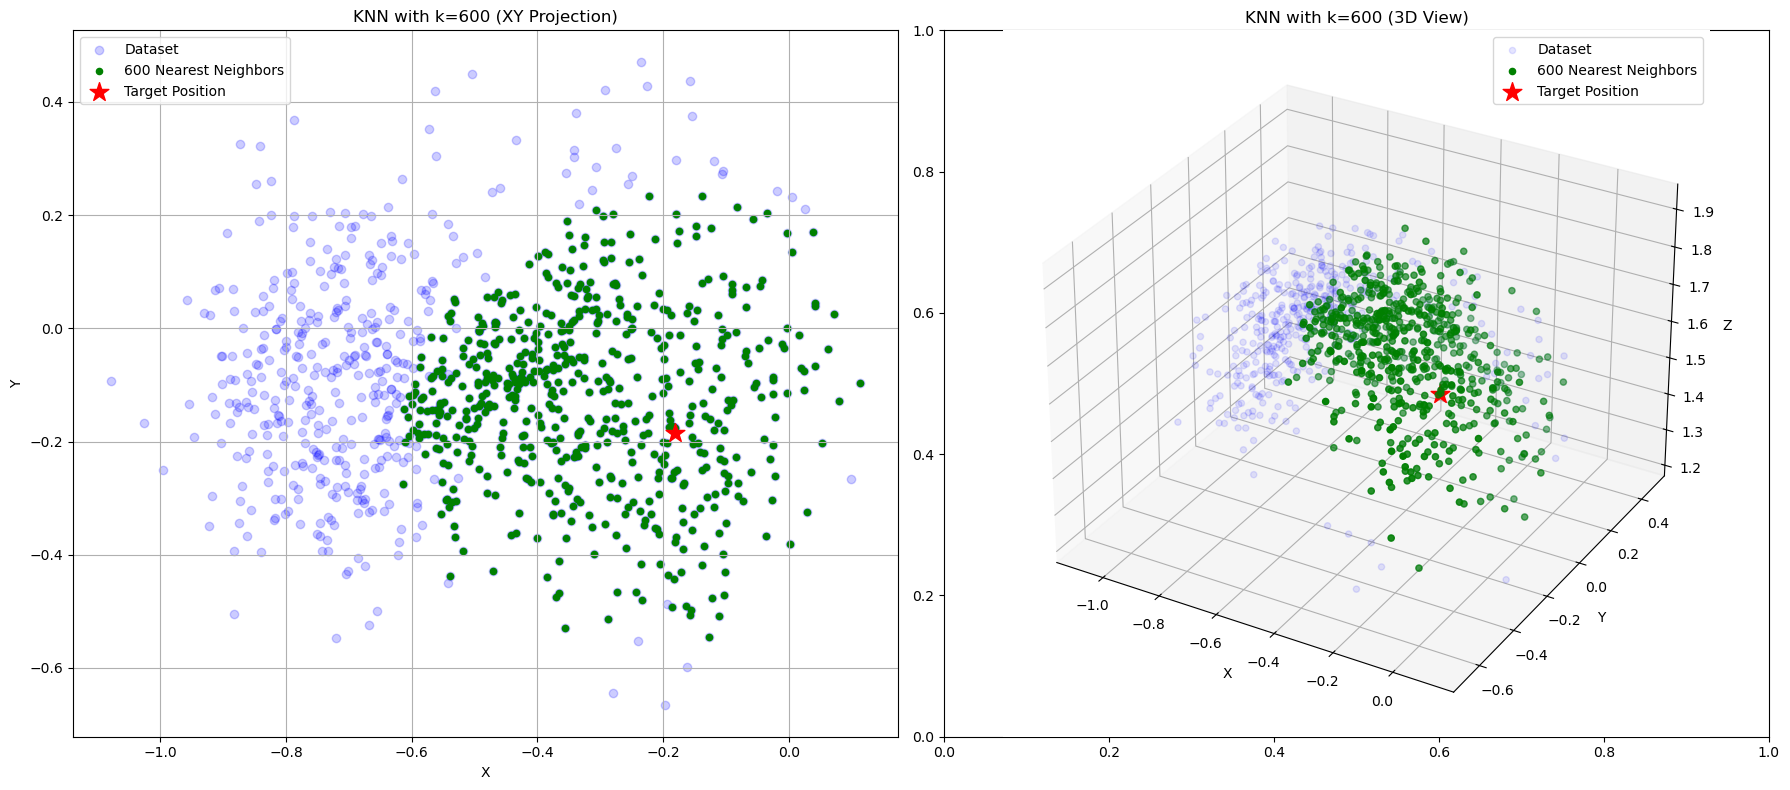

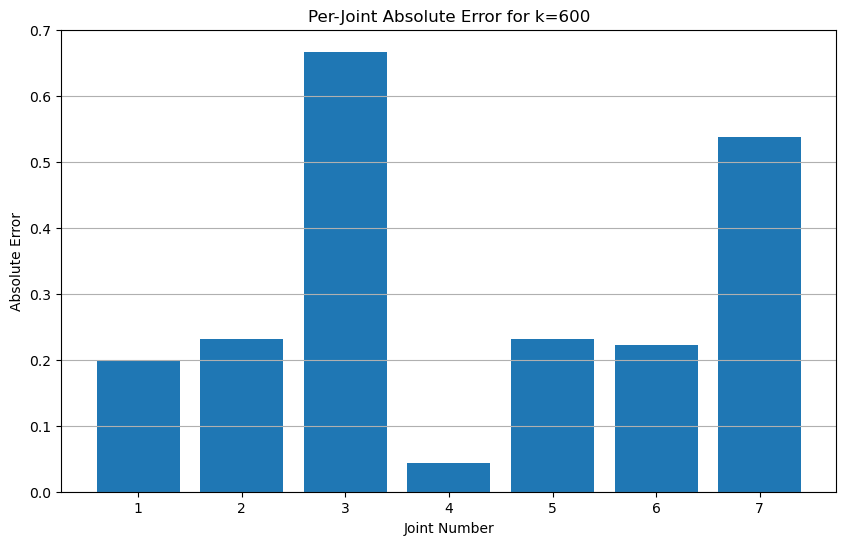

In [8]:
# TODO: discuss your results in your report (5 marks), no code required here, no code required for the report.


# Set specific k value
k = 600

# Apply KNN regression to predict joint angles for the new position
predicted_joint_angles, avg_distance = knn_regression(eef_position, joint_angles, new_eef_pos, k=k)

# Print results
print(f"K value: {k}")
print(f"Predicted joint angles: {predicted_joint_angles}")
print(f"Average distance to {k} nearest neighbors: {avg_distance:.6f}")

# Calculate error metrics between predicted and actual joint angles
mse = np.mean((predicted_joint_angles - actual_joint_angles) ** 2)
mae = np.mean(np.abs(predicted_joint_angles - actual_joint_angles))
print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")

# Create visualization with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Visualization of k-nearest neighbors
ax1.scatter(eef_position[:, 0], eef_position[:, 1], color='blue', alpha=0.2, label='Dataset')

# Get the k nearest neighbors
nn_indices, _ = find_k_nearest_neighbors(eef_position, new_eef_pos, k)
nn_positions = eef_position[nn_indices]

# Plot the nearest neighbors
ax1.scatter(nn_positions[:, 0], nn_positions[:, 1], color='green', s=20, label=f'{k} Nearest Neighbors')

# Plot the target position
ax1.scatter(new_eef_pos[0], new_eef_pos[1], color='red', s=200, marker='*', label='Target Position')

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title(f'KNN with k={k} (XY Projection)')
ax1.legend()
ax1.grid(True)

# Plot 2: 3D visualization
ax2 = plt.subplot(1, 2, 2, projection='3d')
ax2.scatter(eef_position[:, 0], eef_position[:, 1], eef_position[:, 2], color='blue', alpha=0.1, label='Dataset')
ax2.scatter(nn_positions[:, 0], nn_positions[:, 1], nn_positions[:, 2], color='green', s=20, label=f'{k} Nearest Neighbors')
ax2.scatter(new_eef_pos[0], new_eef_pos[1], new_eef_pos[2], color='red', s=200, marker='*', label='Target Position')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title(f'KNN with k={k} (3D View)')
ax2.legend()

plt.tight_layout()
plt.show()

# Plot per-joint errors
joint_errors = np.abs(predicted_joint_angles - actual_joint_angles)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 8), joint_errors)
plt.xlabel('Joint Number')
plt.ylabel('Absolute Error')
plt.title(f'Per-Joint Absolute Error for k={k}')
plt.xticks(range(1, 8))
plt.grid(axis='y')
plt.show()
